<h1><b><center>Auvergne Geoid Modeling using GeoidLab</center></b></h1>
<p style="text-align: center; font-size: 1.2em; color: white;">
    Author: Caleb Kelly<br>
</p>

This Notebook demonstrates the capabilities of `geoidlab` software for geoid computation. For this, we will use the [gridded Bouguer anomaly dataset](https://github.com/aabbak/CSHSOFT/blob/main/anomaly.xyz) graciously made available by [Abbak et al. (2024)](https://link.springer.com/article/10.1007/s12145-024-01328-0).

GeoidLab is a modular and highly automated Python package for geoid. We will demonstrate some of its capabilities, and validate its results against those of [Abbak et al. (2024)](https://link.springer.com/article/10.1007/s12145-024-01328-0).

Enjoy the ride!

# Directory setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path

downloads_dir: Path = Path('downloads').resolve()
results_dir: Path = Path('results').resolve()
figures_dir: Path = results_dir / 'figures'


# Define some parameters here
ellipsoid = 'grs80'
nmax      = 630 # maximum degree of GGM expansion to use for synthesis

# Colormaps

Let's copy and paste a useful function from `geoidlab.cli.commands.plot` for using custom colormaps. This function allows us to use GMT colormaps, our own custom `rainbow` colormap (although this is not much different from GMT_rainbow.cpt), and all of the Matplotlitb's colormaps. To use a colormap, say `viridis`, instead of passing `'viridis'` to `cmap` in the matplotlib call, pass `cmap=get_colormap('viridis')`. This makes more sense if you are using custom colormaps: `cmap=get_colormap('GMT_rainbow.cpt')`.

In [3]:
from geoidlab.mapping.colormaps import bright_rainbow_cmap, cpt_cmap
from matplotlib.colors import Colormap, ListedColormap
import matplotlib.pyplot as plt

CUSTOM_CMAPS: dict[str, ListedColormap] = {
    'bright_rainbow': bright_rainbow_cmap()
}

def get_colormap(cmap_name: str) -> Colormap:
    '''Retrieve colormap by name, handling custom and GMT .cpt colormaps'''
    if cmap_name in CUSTOM_CMAPS:
        return CUSTOM_CMAPS[cmap_name]
    elif cmap_name.endswith('.cpt'):
        return cpt_cmap(cmap_name)
    else:
        try:
            return plt.get_cmap(cmap_name)
        except ValueError:
            raise ValueError(f'Invalid colormap: {cmap_name}. Use --list-cmaps to see available options.')

# Load Gravity Anomaly Data

Typically, geoid modeling will start from processing the gravity measurements: including tide system conversion and gravity reduction. In this Notebook, we will skip most of these steps and go straight to the gridded gravity data as this is what is available. We will also demonstrate in a different Notebook how to go from the gravity observations through gravity reduction to the final geoid model.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.family': 'Arial', 'font.size': 9})

In [5]:
dg_name = downloads_dir/'anomaly.xyz'
Dg_df = pd.read_csv(dg_name, names=['lat', 'lon', 'Dg'], sep=' ')
Dg_df.head()

,lat,lon,Dg
0,47.99,0.01,1.931080
1,47.99,0.03,1.508280
2,47.99,0.05,0.446228
3,47.99,0.07,-2.311170
4,47.99,0.09,-3.772430


In [6]:
lon: np.ndarray = Dg_df['lon'].values
lat: np.ndarray = Dg_df['lat'].values
num_lat_points: int = len(np.unique(lat))
num_lon_points: int = len(np.unique(lon))

print(f'Length of latitudes : {num_lat_points}\nLength of longitudes: {num_lon_points}')

Length of latitudes : 200
Length of longitudes: 300


In [7]:
Dg: np.ndarray = Dg_df['Dg'].values
Dg = Dg.reshape(num_lon_points, num_lat_points, order='F')
Lon: np.ndarray = lon.reshape(num_lon_points, num_lat_points, order='F')
Lat: np.ndarray = lat.reshape(num_lon_points, num_lat_points, order='F')

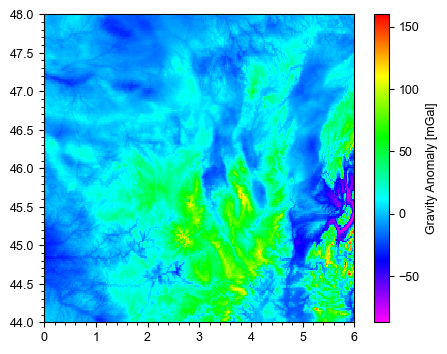

In [8]:
fig_name = figures_dir / 'Dg.png'
cmap = get_colormap('GMT_rainbow.cpt')
plt.figure(figsize=[5,4])
plt.pcolormesh(Lon, Lat, Dg, cmap=cmap)
plt.colorbar(label='Gravity Anomaly [mGal]')
# plt.title('Gravity Anomaly', fontsize=10, fontweight='bold')
plt.grid(which='both', linewidth=0)
plt.minorticks_on()
plt.grid(which='minor', linewidth=0)
plt.savefig(fig_name, dpi=300, bbox_inches='tight')
plt.show()

# Terrain Quantities

One might call use `dem4geoid` from `geoidlab.dem` to create a DEM suited for geoid computation in `GeoidLab`. Let's see how to do this

In [9]:
import warnings
warnings.simplefilter('ignore')
from geoidlab.dem import dem4geoid

In [10]:
help(dem4geoid)

Help on function dem4geoid in module geoidlab.dem:

dem4geoid(bbox, ncfile=None, bbox_off=1, downloads_dir=None, resolution=30, model='srtm30plus', interp_method='slinear') -> xarray.core.dataset.Dataset
    Prepare a DEM for geoid calculation.

    Parameters
    ----------
    bbox          : bounding box of area of interest
                    [xmin, xmax, ymin, ymax]
                    [left, bottom, right, top]
                    [W, E, S, N]
    ncfile        : path to DEM netCDF file
    bbox_off      : offset for bounding box (in degrees)
    downloads_dir : directory to download the file to
    resolution    : Resolution to resample the DEM
    model         : name of the DEM model
                     - srtm30plus
                     - srtm
                     - cop
                     - nasadem
                     - gebco
    interp_method : interpolation method

    Returns
    -------
    dem       : xarray dataset of the DEM

    Notes
    -----
    1. If DEM is alr

The bounding box parameter in `dem4geoid` and `geoidlab` in general takes four inputs in the form [W, E, S, N] or [min_lon, max_lon, min_lat, max_lat].

In [11]:
# bbox = [
#     round(lon.min()), round(lon.max()), 
#     round(lat.min()), round(lat.max())
# ]
bbox = [
    lon.min(), lon.max(),
    lat.min(), lat.max()
]

# bbox = [1-0.01, 5-0.01, 45-.01, 47-.01]
# bbox = [0, 6, 44, 48]

# # bbox = [1.5, 4.5, 45, 47]
bbox

[0.01, 5.99, 44.01, 47.99]

Let's demonstrate how to use dem4geoid to create a DEM for the geoid of Auvergne. If your internet connection is not good, it is strongly recommended to use SRTM30PLUS (i.e., `model='srtm30plus'`). In keeping with Abbak et al. (2024), we will use a resolution of 0.02 degrees. Since `dem4geoid` expects `resolution` in seconds, we will convert 0.02 degrees to seconds and pass that to `resolution`.

In [12]:
def deg2seconds(resolution) -> float:
    '''Convert degrees to seconds'''
    return resolution * 3600

resolution = deg2seconds(0.02)
print(f'0.02 degrees translates into {resolution:.2f} arc-seconds')

0.02 degrees translates into 72.00 arc-seconds


In [13]:
bbox_off = 0

dem = dem4geoid(
    bbox=bbox, 
    downloads_dir=downloads_dir,
    resolution=resolution, bbox_off=bbox_off,
    model='srtm'
)
dem

srtm_dem.nc exists and covers bbox. Using local copy.

Creating xarray dataset of DEM with buffer of 0 degree(s)

Aligning DEM to bounding box and resampling DEM to 72.0 arc-seconds...
DEM alignment and resampling completed in 11.12 seconds.



<xarray.Dataset> Size: 484kB
Dimensions:      (y: 200, x: 300)
Coordinates:
    band         int64 8B 1
    spatial_ref  int64 8B 0
  * x            (x) float64 2kB 0.01 0.03 0.05 0.07 ... 5.93 5.95 5.97 5.99
  * y            (y) float64 2kB 44.01 44.03 44.05 44.07 ... 47.95 47.97 47.99
Data variables:
    z            (y, x) float64 480kB 136.0 138.0 137.0 ... 308.0 290.0 307.0

Notice that we get a message saying that "srtm_dem.nc" exists and covers bbox. Using local copy.". Under the hood, `geoidlab.dem` checks to see if the requested DEM exists in the provided directory. If there is a file with the same name, it checks to see if this file covers the specified `bbox`. If it does, it skips download and goes on to create an `xarray` dataset of the DEM. You may not see this if you are running this Notebook for the first time without the DEM file.

Let's visualize the DEM.

In [14]:
xlon = [1.51, 4.49]
ylat = [45.01, 46.99]

corners = [
    (xlon[0], ylat[0]),
    (xlon[1], ylat[0]),
    (xlon[1], ylat[1]),
    (xlon[0], ylat[1]),
    (xlon[0], ylat[0])
]

corner_lons, corner_lats = zip(*corners)

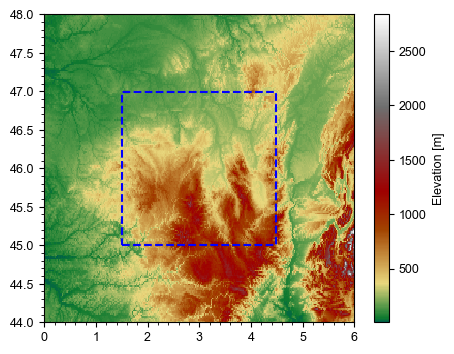

In [15]:
figname = figures_dir / 'topography.png'
plt.figure(figsize=[5,4])
plt.pcolormesh(dem.x, dem.y, dem.z, cmap=get_colormap('DEM_poster.cpt'))
plt.colorbar(label='Elevation [m]')
# plt.title('Auvergne Elevation', fontweight='bold')
plt.grid(which='both', linewidth=0)
plt.minorticks_on()
plt.grid(which='minor', linewidth=0)
plt.plot(corner_lons, corner_lats, 'b--')
plt.savefig(figname, dpi=300, bbox_inches='tight')
plt.show()

We can go on ahead to perform terrain correction (direct topographic effect, DTE) and the indirect effect (primary indirect topographic effect, PITE). Some of the optional corrections also depend on topography, and are grouped with terrain effects in `terrain.py` in `geoidlab`. So, we will go ahead and compute them here. Here's a list of the quantities we will compute:
- Direct Topographic Effect (DTE): also known as terrain correction
- Primary Indirect Topographic Effect (PITE): indirect effect on the geoid
- Secondary Indirect Topographic Effect (SITE)
- Direct Atmospheric Effect (DAE)

In [16]:
from geoidlab import terrain

In [17]:
tq = terrain.TerrainQuantities(
    ori_topo=dem, ellipsoid=ellipsoid, 
    radius=200, 
    bbox_off=0,
    overwrite=True,
    window_mode='fixed',
    proj_dir=str(Path('../Auvergne').resolve()),
)

[WARNING] bbox_offset=0 or computation grid matches original grid. Forcing window_mode='radius' for robust windowing.


In [18]:
dte = tq.terrain_correction(parallel=True)

Computing terrain correction...
########
Completed.
Saving terrain correction to /Users/kelly/Documents/GeoidComp/Auvergne/TC.nc...
Terrain correction computation completed.


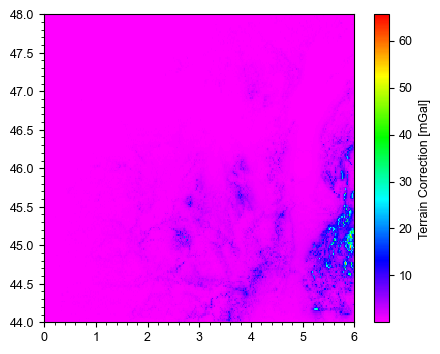

In [60]:
figname = figures_dir / 'TC.png'
plt.figure(figsize=[5,4])
plt.pcolormesh(tq.LonP, tq.LatP, dte, cmap=get_colormap('GMT_rainbow.cpt'))
plt.colorbar(label='Terrain Correction [mGal]')
# plt.title('Terrain Correction', fontsize=10, fontweight='bold')
plt.grid(which='both', linewidth=0)
plt.minorticks_on()
plt.grid(which='minor', linewidth=0)
plt.savefig(figname, dpi=300, bbox_inches='tight')
plt.show()

In [20]:
bbox1 = [1.5, 4.5, 45, 47]
tq1 = terrain.TerrainQuantities(
    ori_topo=dem, ellipsoid=ellipsoid, 
    radius=200, 
    bbox_off=1,
    overwrite=True,
    window_mode='radius',
    proj_dir=str(Path('../Auvergne').resolve()),
    sub_grid=bbox1
)

pite = tq1.indirect_effect()
# pite = np.fliplr(pite.T)

Computing potential change of irregular part...
###
Completed.
Saving the indirect effect to /Users/kelly/Documents/GeoidComp/Auvergne/N_ind.nc...
Indirect effect computation completed.


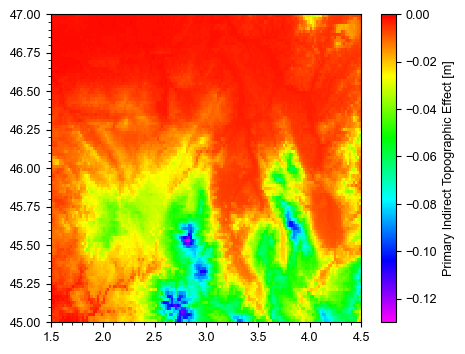

In [21]:
figname: Path = figures_dir / 'PITE.png'
plt.figure(figsize=[5,4])
plt.pcolormesh(tq1.LonP, tq1.LatP, pite, cmap=get_colormap('GMT_rainbow.cpt'), vmin=-0.13, vmax=0)
plt.colorbar(label='Primary Indirect Topographic Effect [m]')
# plt.title('Primary Indirect Topographic Effect', fontsize=10, fontweight='bold')
plt.grid(which='both', linewidth=0)
plt.minorticks_on()
plt.grid(which='minor', linewidth=0)
plt.savefig(figname, dpi=300, bbox_inches='tight')
plt.show()

In [22]:
tq.sub_grid = bbox
site = tq.secondary_indirect_effect()

Computing the secondary indirect effect on gravity...
Secondary indirect effect on gravity computation completed.


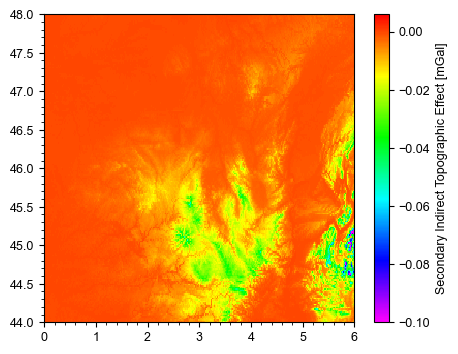

In [23]:
figname = figures_dir / 'SITE.png'
plt.figure(figsize=[5,4])
plt.pcolormesh(tq.LonP, tq.LatP, site, cmap=get_colormap('GMT_rainbow.cpt'), vmin=-0.10, vmax=0.006)
plt.colorbar(label='Secondary Indirect Topographic Effect [mGal]')
# plt.title('Secondary Indirect Topographic Effect', fontsize=10, fontweight='bold')
plt.grid(which='both', linewidth=0)
plt.minorticks_on()
plt.grid(which='minor', linewidth=0)
plt.savefig(figname, dpi=300, bbox_inches='tight')
plt.show()

In [24]:
dae = tq.atm_correction_grid(method = 'noaa')

Saving atmospheric corrections to /Users/kelly/Documents/GeoidComp/Auvergne/Dg_atm.nc...
Atmospheric correction computation completed.


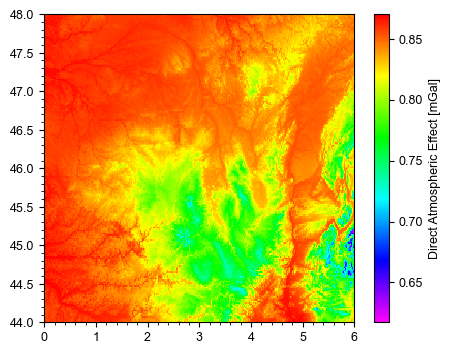

In [25]:
figname = figures_dir / 'DAE.png'
plt.figure(figsize=[5,4])
plt.pcolormesh(tq.LonP, tq.LatP, dae, cmap=get_colormap('GMT_rainbow.cpt'))
plt.colorbar(label='Direct Atmospheric Effect [mGal]')
# plt.title('Direct Atmospheric Effect', fontsize=10, fontweight='bold')
plt.grid(which='both', linewidth=0)
plt.minorticks_on()
plt.grid(which='minor', linewidth=0)
plt.savefig(figname, dpi=300, bbox_inches='tight')
plt.show()

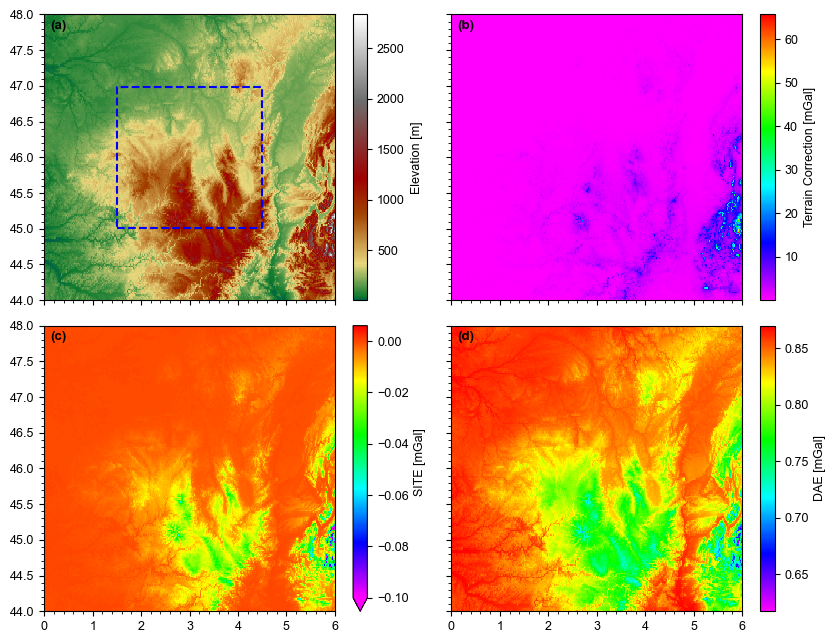

In [ ]:
# # You do not need this. Used for the GeoidLab reference paper.

# terrain_effects = [Dg, dte, site, dae]
# effect_names = ['Elevation', 'Terrain Correction', 'SITE', 'DAE']
# units = ['m', 'mGal', 'mGal', 'mGal']
# annotate = ['(a)', '(b)', '(c)', '(d)']

# fig, axs = plt.subplots(2, 2, figsize=[8.5, 6.5], sharex=True, sharey=True)


# for i, ax in enumerate(axs.reshape(-1)):
#     if i == 0:
#         im = ax.pcolormesh(dem.x, dem.y, dem.z, cmap=get_colormap('DEM_poster.cpt'))
#         ax.plot(corner_lons, corner_lats, 'b--')
#     else:
#         vmin = -0.10 if i == 2 else None
#         vmax = 0.006 if i == 2 else None
#         im = ax.pcolormesh(tq.LonP, tq.LatP, terrain_effects[i], cmap=get_colormap('GMT_rainbow.cpt'), vmin=vmin, vmax=vmax)
#     fig.colorbar(im, ax=ax, label=effect_names[i] + f' [{units[i]}]', extend='min' if i == 2 else None)
#     # ax.set_title(effect_names[i], fontsize=10, fontweight='bold')
#     ax.text(0.02, 0.98, annotate[i], ha='left', va='top', transform=ax.transAxes, fontsize=9.5, fontweight='bold')
#     ax.grid(which='both', linewidth=0)
#     ax.minorticks_on()
#     ax.grid(which='minor', linewidth=0)
    
# fig.tight_layout()
# fig.savefig(figures_dir / 'topo_terrain_effects.png', dpi=300, bbox_inches='tight')
# plt.show()

# Reference Quantities

Now, we will synthesize gravity anomalies and geoid height from a global geopotential model (GGM). `geoidlab` seamlessly handles GGM download from ICGEM. Users only need to pass the exact name of the model from ICGEM website. Abbak et al. (2024) used XGM2019. So let's go on ahead and use this model. On ICGEM, this model is called `XGM2019e_2159`. 

See [ICGEM](https://icgem.gfz-potsdam.de/tom_longtime) for a list of models.

We can use `icgem` to download and read a GGM. Here's an example.

However, a cool thing about `geoidlab` is that you can pass it the name and it will download the model if it doesn't exist prior to synthesizing a specified functional. We will use `ggm` from `geoidlab`. This takes `grav_data` parameter, which is simply the longitude, latitude, and height of the points at which you want to synthesize these functionals. For gravity anomalies, we will use the same lon-lat as `Dg_df`. And for geoid heights, we will create a new grid based `tq1.LonP` and `tq1.LatP`. Let's see how to use this for GGM anomalies and geoid undulations. 

In [26]:
from geoidlab import ggm as ggm_tools

In [27]:
model_name = 'XGM2019.gfc'
data = np.array([lon, lat, np.zeros(len(lon))]).T
grav_data = pd.DataFrame(data, columns=['lon', 'lat', 'height'])
ggm = ggm_tools.GlobalGeopotentialModel(
    model_name=model_name,
    grav_data=grav_data,
    ellipsoid=ellipsoid,
    nmax=nmax,
    model_dir=downloads_dir,
    chunk_size=400,
)
Dg_ggm  = ggm.gravity_anomaly(parallel=False)

Large array detected (60000 points). Processing in batches of 1000 to avoid memory issues...
Processing batch 1/60 (points 1-1000)...


Computing gravity anomalies: 100%|██████████| 629/629 [00:03<00:00, 199.98it/s]


Processing batch 2/60 (points 1001-2000)...


Computing gravity anomalies: 100%|██████████| 629/629 [00:02<00:00, 218.75it/s] 


Processing batch 3/60 (points 2001-3000)...


...

Processing batch 59/60 (points 58001-59000)...


Computing gravity anomalies: 100%|██████████| 629/629 [00:03<00:00, 188.52it/s] 


Processing batch 60/60 (points 59001-60000)...


Computing gravity anomalies: 100%|██████████| 629/629 [00:03<00:00, 189.37it/s] 


Completed processing all 60 batches.


In [28]:
model_name = 'XGM2019.gfc'
data = np.array([tq1.LonP.flatten(), tq1.LatP.flatten(), np.zeros(len(tq1.LatP.flatten()))]).T
grav_data = pd.DataFrame(data, columns=['lon', 'lat', 'height'])
ggm = ggm_tools.GlobalGeopotentialModel(
    model_name=model_name,
    grav_data=grav_data,
    ellipsoid=ellipsoid,
    nmax=nmax,
    model_dir=downloads_dir,
    chunk_size=50
)

N_ggm   = ggm.geoid(parallel=False, icgem=False)

Large array detected (15000 points). Processing in batches of 1000 to avoid memory issues...
Processing batch 1/15 (points 1-1000)...
Using Bruns' method with zero-degree correction to calculate geoid height...



Computing disturbing potential: 100%|██████████| 629/629 [00:03<00:00, 189.13it/s] 


Reference geoid computed successfully!
Processing batch 2/15 (points 1001-2000)...
Using Bruns' method with zero-degree correction to calculate geoid height...



Computing disturbing potential: 100%|██████████| 629/629 [00:03<00:00, 188.48it/s] 


Reference geoid computed successfully!
Processing batch 3/15 (points 2001-3000)...
Using Bruns' method with zero-degree correction to calculate geoid height...



...

Reference geoid computed successfully!
Processing batch 14/15 (points 13001-14000)...
Using Bruns' method with zero-degree correction to calculate geoid height...



Computing disturbing potential: 100%|██████████| 629/629 [00:03<00:00, 191.47it/s] 


Reference geoid computed successfully!
Processing batch 15/15 (points 14001-15000)...
Using Bruns' method with zero-degree correction to calculate geoid height...



Computing disturbing potential: 100%|██████████| 629/629 [00:03<00:00, 186.56it/s] 


Reference geoid computed successfully!
Completed processing all 15 batches.


Great! Our Dg_ggm and N_ggm have been successfully computed. We now need to reshape them and move on to Stokes' formula!

In [29]:
Dg_ggm = Dg_ggm.reshape(num_lon_points, num_lat_points, order='F')
N_ggm = N_ggm.reshape(tq1.LonP.shape)

In [30]:
import xarray as xr

N_ggm_xr = xr.DataArray(
    N_ggm,
    coords={'lat': np.unique(tq1.LatP), 'lon': np.unique(tq1.LonP)},
    dims=['lat', 'lon'],
    name='N_ggm',
    # attrs='ICGEM version: with topographic correction'
).to_dataset()

N_ggm_xr.to_netcdf(results_dir/'N_ggm.nc')

In [31]:
import xarray as xr

Dg_ggm_xr = xr.DataArray(
    np.flipud(Dg_ggm.T),
    coords={'lat': np.unique(Lat), 'lon': np.unique(Lon)},
    dims=['lat', 'lon'],
    name='Dg'
).to_dataset()

Dg_ggm_xr.to_netcdf(results_dir/'Dg_ggm.nc')

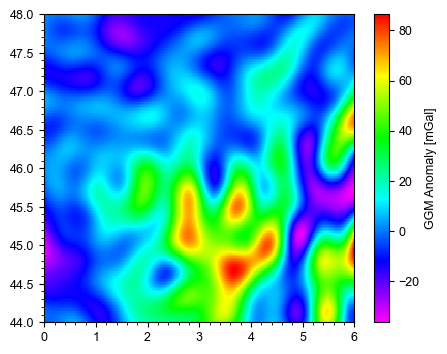

In [32]:
figname = figures_dir / 'Dg_ggm.png'
plt.figure(figsize=[5,4])
plt.pcolormesh(Lon, Lat, Dg_ggm, cmap=get_colormap('GMT_rainbow.cpt'))
plt.colorbar(label='GGM Anomaly [mGal]')
# plt.title('Reference Gravity Anomaly', fontsize=10, fontweight='bold')
plt.grid(which='both', linewidth=0)
plt.minorticks_on()
plt.grid(which='minor', linewidth=0)
plt.savefig(figname, dpi=300, bbox_inches='tight')
plt.show()

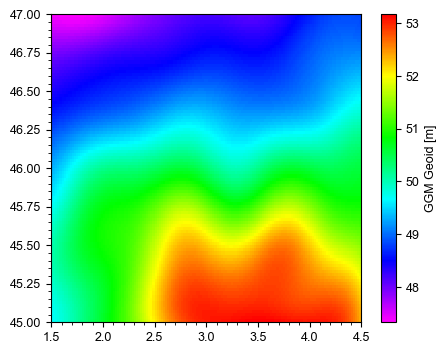

In [33]:
N_ggm = N_ggm.reshape(tq1.LonP.shape)
figname = figures_dir / 'N_ggm.png'
plt.figure(figsize=[5,4])
plt.pcolormesh(tq1.LonP, tq1.LatP, N_ggm, cmap=get_colormap('GMT_rainbow.cpt'))
plt.colorbar(label='GGM Geoid [m]')
# plt.title('Reference Geoid', fontsize=10, fontweight='bold')
plt.grid(which='both', linewidth=0)
plt.minorticks_on()
plt.grid(which='minor', linewidth=0)
plt.savefig(figname, dpi=300, bbox_inches='tight')
plt.show()

In [34]:
data = np.array([lon, lat, np.zeros(len(lon))]).T
grav_data = pd.DataFrame(data, columns=['lon', 'lat', 'height'])
ggm = ggm_tools.GlobalGeopotentialModel(
    model_name=model_name,
    grav_data=grav_data,
    ellipsoid=ellipsoid,
    nmax=nmax,
    zonal_harmonics=True,
    model_dir=downloads_dir,
    chunk_size=50
)

Dg_ell   = ggm.ellipsoidal_correction()

Large array detected (60000 points). Processing in batches of 1000 to avoid memory issues...
Forcing parallel=False for large arrays to prevent memory issues.
Processing batch 1/60 (points 1-1000)...
Ellipsoidal correction requires the disturbing potential and its derivative.
Computing disturbing potential...


Computing disturbing potential: 100%|██████████| 629/629 [00:03<00:00, 186.99it/s] 


Computing the first derivative of disturbing potential with respect to colatitude...


Computing disturbing potential: 100%|██████████| 629/629 [00:03<00:00, 192.32it/s] 


Computing ellipsoidal correction...
Ellipsoidal correction computed successfully.
Processing batch 2/60 (points 1001-2000)...
Ellipsoidal correction requires the disturbing potential and its derivative.
Computing disturbing potential...


...

Computing ellipsoidal correction...
Ellipsoidal correction computed successfully.
Processing batch 60/60 (points 59001-60000)...
Ellipsoidal correction requires the disturbing potential and its derivative.
Computing disturbing potential...


Computing disturbing potential: 100%|██████████| 629/629 [00:03<00:00, 198.26it/s] 


Computing the first derivative of disturbing potential with respect to colatitude...


Computing disturbing potential: 100%|██████████| 629/629 [00:03<00:00, 189.56it/s]


Computing ellipsoidal correction...
Ellipsoidal correction computed successfully.
Completed processing all 60 batches.


In [35]:
Dg_ell = Dg_ell.reshape(num_lon_points, num_lat_points, order='F')

In [36]:
import xarray as xr

Dg_ell_xr = xr.DataArray(
    np.flipud(Dg_ell.T),
    coords={'lat': np.unique(Lat), 'lon': np.unique(Lon)},
    dims=['lat', 'lon'],
    name='ell'
).to_dataset()

Dg_ell_xr.to_netcdf(results_dir/'Dg_ell.nc')

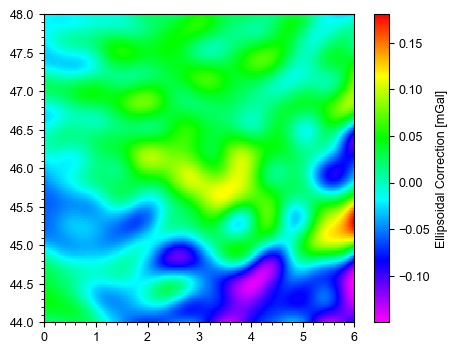

In [37]:
figname = figures_dir / 'ELL.png'
plt.figure(figsize=[5,4])
plt.pcolormesh(Lon, Lat, Dg_ell, cmap=get_colormap('GMT_rainbow.cpt'))
plt.colorbar(label='Ellipsoidal Correction [mGal]')
# plt.title('Ellipsoidal Correction', fontsize=10, fontweight='bold')
plt.grid(which='both', linewidth=0)
plt.minorticks_on()
plt.grid(which='minor', linewidth=0)
plt.savefig(figname, dpi=300, bbox_inches='tight')
plt.show()

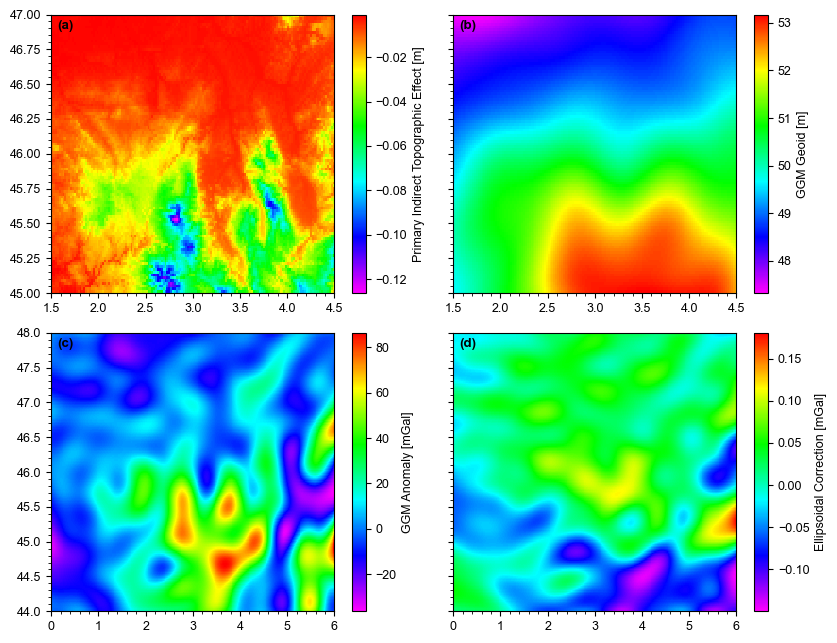

In [ ]:
# reference_quantities = [pite, N_ggm, Dg_ggm, Dg_ell]

# ref_names = ['Primary Indirect Topographic Effect [m]', 'GGM Geoid [m]', 'GGM Anomaly [mGal]', 'Ellipsoidal Correction [mGal]']
# annotate = ['(a)', '(b)', '(c)', '(d)']

# fig, axs = plt.subplots(2, 2, figsize=[8.5, 6.5], sharex=False, sharey='row')

# for i, ax in enumerate(axs.flat):
#     if i == 2 or i == 3:
#         im = ax.pcolormesh(Lon, Lat, reference_quantities[i], cmap=get_colormap('GMT_rainbow.cpt'))
#     else:
#         im = ax.pcolormesh(tq1.LonP, tq1.LatP, reference_quantities[i], cmap=get_colormap('GMT_rainbow.cpt'))
    
#     fig.colorbar(im, ax=ax, label=ref_names[i])
#     ax.text(0.02, 0.98, annotate[i], ha='left', va='top', transform=ax.transAxes, fontsize=9.5, fontweight='bold')
#     ax.grid(which='both', linewidth=0)
#     ax.minorticks_on()
#     ax.grid(which='minor', linewidth=0)

# fig.tight_layout()
# figname = figures_dir / 'reference_quantities.png'
# fig.savefig(figname, dpi=300, bbox_inches='tight')
# plt.show()

# The Geoid

In [39]:
from geoidlab import geoid
import xarray as xr

In [40]:
# Apply corrections to Dg
Dg += Dg_ell + np.fliplr(dae.T) + np.fliplr(site.T)
Dg_res = Dg - Dg_ggm - np.fliplr(dte.T)

In [41]:
# Create xarray dataset object using Dg_res
Dg_res_ds = xr.Dataset(
    {
        "Dg": (["lat", "lon"], np.flipud(Dg_res.T))
    },
    coords={
        "lat": np.unique(lat),
        "lon": np.unique(lon)
    }
)

Dg_res_ds.to_netcdf(results_dir/'Dg_res.nc')

Dg_res_ds

<xarray.Dataset> Size: 484kB
Dimensions:  (lat: 200, lon: 300)
Coordinates:
  * lat      (lat) float64 2kB 44.01 44.03 44.05 44.07 ... 47.95 47.97 47.99
  * lon      (lon) float64 2kB 0.01 0.03 0.05 0.07 0.09 ... 5.93 5.95 5.97 5.99
Data variables:
    Dg       (lat, lon) float64 480kB 2.919 2.624 3.254 ... 4.622 2.994 3.06

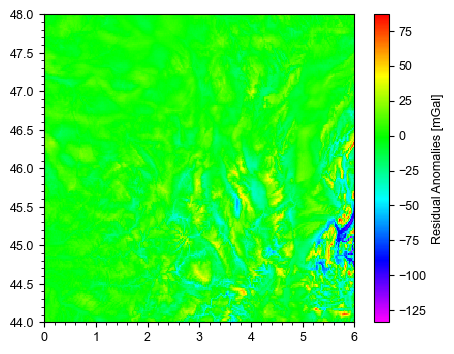

In [42]:
figname = figures_dir / 'Dg_res.png'
plt.figure(figsize=[5,4])
plt.pcolormesh(Dg_res_ds.lon, Dg_res_ds.lat, Dg_res_ds['Dg'], cmap=get_colormap('GMT_rainbow.cpt'))
plt.colorbar(label='Residual Anomalies [mGal]')
# plt.title('Residual Anomalies', fontsize=10, fontweight='bold')
plt.grid(which='both', linewidth=0)
plt.minorticks_on()
plt.grid(which='minor', linewidth=0)
plt.savefig(figname, dpi=300, bbox_inches='tight')
plt.show()

In [43]:
import xarray as xr
import time

# Abbak et al. (2024) use a different degree for solving Stokes' integral. Let's set L = 145 in our solution
# for consistency
L = 145 

subgrid = [tq1.LonP.min(), tq1.LonP.max(), tq1.LatP.min(), tq1.LatP.max()]
geoid_models: dict = {}
for method in ['og', 'ml', 'wg', 'hg']:
    res_geoid = geoid.ResidualGeoid(
        res_anomaly=Dg_res_ds,
        method=method,
        sph_cap=0.95,
        nmax=L,
        window_mode='cap',
        sub_grid=subgrid
    )
    N_res: np.ndarray = res_geoid.compute_geoid()
    
    N_res_ds = xr.Dataset(
        {
            'N_res': (['lat', 'lon'], N_res)
        },
        coords={
            'lat': np.unique(tq1.LatP),
            'lon': np.unique(tq1.LonP)
        }
    )
    residual_fname = results_dir/f'N_res_{method}.nc'
    residual_fname.unlink(missing_ok=True)
    N_res_ds.to_netcdf(residual_fname)
    geoid_models[method] = N_res_ds
    print(f'{method.upper()} results saved to {results_dir}/N_res_{method}.nc')
    time.sleep(5)

Computing inner zone...
Inner zone computation completed.
Computing far zone using: Original Stokes' method...


Computing far zone contribution: 100%|██████████| 100/100 [00:30<00:00,  3.30it/s]


Far zone computation completed.
OG results saved to /Users/kelly/Documents/GeoidComp/Auvergne/results/N_res_og.nc
Computing inner zone...
Inner zone computation completed.
Computing far zone using: Meissl method...


Computing far zone contribution: 100%|██████████| 100/100 [00:29<00:00,  3.44it/s]


Far zone computation completed.
ML results saved to /Users/kelly/Documents/GeoidComp/Auvergne/results/N_res_ml.nc
Computing inner zone...
Inner zone computation completed.
Computing far zone using: Wong & Gore method...


Computing far zone contribution: 100%|██████████| 100/100 [03:24<00:00,  2.04s/it]


Far zone computation completed.
WG results saved to /Users/kelly/Documents/GeoidComp/Auvergne/results/N_res_wg.nc
Computing inner zone...
Inner zone computation completed.
Computing far zone using: Heck & Gruninger method...


Computing far zone contribution: 100%|██████████| 100/100 [03:32<00:00,  2.12s/it]


Far zone computation completed.
HG results saved to /Users/kelly/Documents/GeoidComp/Auvergne/results/N_res_hg.nc


In [44]:
fnames: list[Path] = list(Path(results_dir).glob('N_res_*.nc'))
methods: list = [fname.stem.split('_')[-1] for fname in fnames]
res_geoid_models: dict = {}

for fname, method in zip(fnames, methods):
    res_geoid_models[method] = xr.open_dataset(fname)

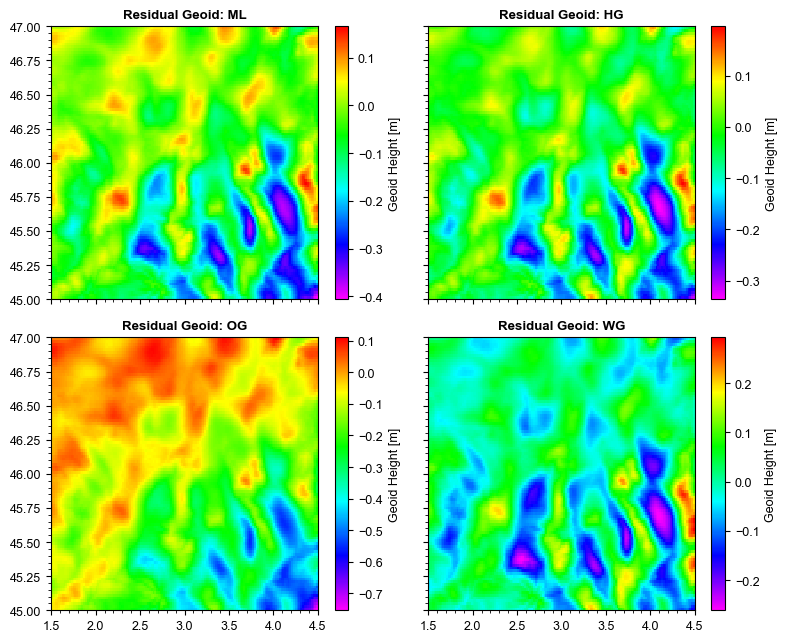

In [45]:
fig, axs = plt.subplots(2, 2, figsize=[8, 6.5], sharex=True, sharey=True)
axs = axs.ravel()

for (key, value), ax, fname in zip(res_geoid_models.items(), axs, fnames):
    method = fname.stem.split('_')[-1].upper()
    im = ax.pcolormesh(value.lon, value.lat, value.N_res, cmap=get_colormap('GMT_rainbow.cpt'))
    fig.colorbar(im, ax=ax, label='Geoid Height [m]')
    ax.set_title(f'Residual Geoid: {method.upper()}', fontweight='bold', fontsize=9.5)
    ax.grid(which='both', linewidth=0)
    ax.minorticks_on()
    ax.grid(which='minor', linewidth=0)

fig.tight_layout()
plt.savefig(figures_dir / 'N_res_all.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# for method, ds in res_geoid_models.items():
#     print(f'{method.upper()} Geoid: min={ds.N_res.min().values:.3f}, max={ds.N_res.max().values:.3f}, '
#           f'mean={ds.N_res.mean().values:.3f}, median={np.median(ds.N_res.values):.3f}, '
#           f'std={ds.N_res.std().values:.3f}')

ML Geoid: min=-0.406, max=0.166, mean=-0.057, median=-0.035, std=0.095
HG Geoid: min=-0.336, max=0.197, mean=-0.033, median=-0.019, std=0.082
OG Geoid: min=-0.754, max=0.110, mean=-0.140, median=-0.099, std=0.149
WG Geoid: min=-0.262, max=0.293, mean=0.004, median=0.005, std=0.077


In [46]:
fnames: list[Path] = list(Path(results_dir).glob('N_res_*.nc'))
methods: list = [fname.stem.split('_')[-1] for fname in fnames]
geoid_models: dict = {}

for fname, method in zip(fnames, methods):
    geoid_models[method] = xr.open_dataset(fname)

In [47]:
final_geoid_models: dict = {}

for method, Nres in geoid_models.items():
    print(f'Calculating the geoid for {method.upper()}...')
    N1 = Nres['N_res'].values + N_ggm + pite
    final_geoid_models[method] = N1
    print(f'Saving {method.upper()} geoid to {results_dir}/N_{method}.nc')
    N_ds = xr.Dataset(
        {
            'N': (['lat', 'lon'], N1)
        },
        coords={
            'lat': np.unique(tq1.LatP),
            'lon': np.unique(tq1.LonP)
        }
    )
    geoid_fname = results_dir / f'N_{method}.nc'
    geoid_fname.unlink(missing_ok=True)
    print(f'Saving {geoid_fname}')
    N_ds.to_netcdf(geoid_fname)

Calculating the geoid for ML...
Saving ML geoid to /Users/kelly/Documents/GeoidComp/Auvergne/results/N_ml.nc
Saving /Users/kelly/Documents/GeoidComp/Auvergne/results/N_ml.nc
Calculating the geoid for HG...
Saving HG geoid to /Users/kelly/Documents/GeoidComp/Auvergne/results/N_hg.nc
Saving /Users/kelly/Documents/GeoidComp/Auvergne/results/N_hg.nc
Calculating the geoid for OG...
Saving OG geoid to /Users/kelly/Documents/GeoidComp/Auvergne/results/N_og.nc
Saving /Users/kelly/Documents/GeoidComp/Auvergne/results/N_og.nc
Calculating the geoid for WG...
Saving WG geoid to /Users/kelly/Documents/GeoidComp/Auvergne/results/N_wg.nc
Saving /Users/kelly/Documents/GeoidComp/Auvergne/results/N_wg.nc


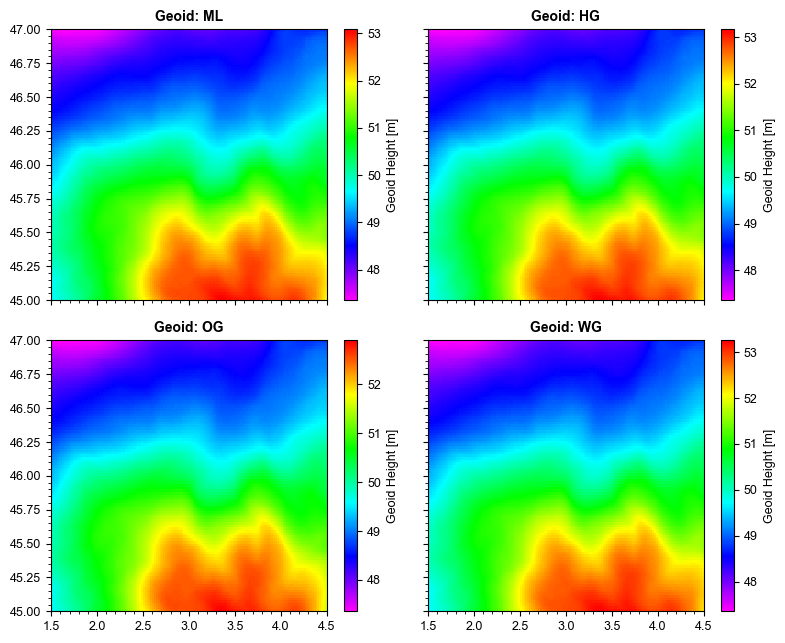

In [48]:
fig, axs = plt.subplots(2, 2, figsize=[8, 6.5], sharex=True, sharey=True)
axs = axs.ravel()

for (key, value), ax in zip(final_geoid_models.items(), axs):
    method = key.upper()
    im = ax.pcolormesh(Nres.lon, Nres.lat, value, cmap=get_colormap('GMT_rainbow.cpt'))
    fig.colorbar(im, ax=ax, label='Geoid Height [m]')
    ax.set_title(f'Geoid: {method.upper()}', fontweight='bold', fontsize=10)
    ax.grid(which='both', linewidth=0)
    ax.minorticks_on()
    ax.grid(which='minor', linewidth=0)

fig.tight_layout()
plt.savefig(figures_dir / 'N_all.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# for method, ds in final_geoid_models.items():
#     print(f'{method.upper()} Geoid: min={ds.min():.3f}, max={ds.max():.3f}, '
#           f'mean={ds.mean():.3f}, median={np.median(ds):.3f}, '
#           f'std={ds.std():.3f}')

ML Geoid: min=47.355, max=53.087, mean=50.195, median=50.079, std=1.439
HG Geoid: min=47.353, max=53.174, mean=50.219, median=50.096, std=1.461
OG Geoid: min=47.357, max=52.900, mean=50.111, median=50.014, std=1.374
WG Geoid: min=47.352, max=53.256, mean=50.255, median=50.126, std=1.490


# Validation

Great! Now that we have computed our geoid models, we will go on ahead and use the GNSS/leveling data [here](https://github.com/aabbak/CSHSOFT/blob/main/gnss.dat) for validation. We assume that the last column of `gnss.dat` is the geometric geoid undulations estimated as $N = h - H$, where $h$ and $H$ are the ellipsoidal and orthometric/physical heights respectively. Hopefully we can verify this assumption from the validation!

This section of the Notebook is designed to be as standalone as possible. If you have already exectuted the previous cells, you would have saved NetCDF files into `<work-dir/results>` directory. So we will load the required NetCDF files for the validation task. 

## Load Data

First, let's load the required datasets for validation. These will be our geoid models and the `gnss.dat` data that we downloaded from [here](https://github.com/aabbak/CSHSOFT/blob/main/gnss.dat).

In [49]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from pathlib import Path

plt.rcParams.update({'font.family': 'Arial', 'font.size': 9})


# Directory setup
downloads_dir: Path = Path('downloads')
results_dir: Path = Path('results')

In [50]:
gnss_fname: Path = downloads_dir / 'gnss.dat'
gnss_df: pd.DataFrame = pd.read_csv(gnss_fname, delim_whitespace=True, comment='#', header=None)
gnss_df.columns = ['lat', 'lon', 'N']
gnss_df.head()

,lat,lon,N
0,45.125312,1.719562,49.296
1,46.212787,1.895712,48.434
2,46.742402,1.824359,47.169
3,46.226090,2.663530,48.920
4,45.718828,3.016851,50.729


In [51]:
methods = ['hg', 'wg', 'ml', 'og']
fnames: list[str] = [f'N_{method}.nc' for method in methods]
geoid_fnames: list[Path] = [results_dir/fname for fname in fnames]
geoid_fnames

[PosixPath('results/N_hg.nc'),
 PosixPath('results/N_wg.nc'),
 PosixPath('results/N_ml.nc'),
 PosixPath('results/N_og.nc')]

In [52]:
geoid_dict: dict = {}
for gname, method in zip(geoid_fnames, methods):
    geoid_dict[method] = xr.open_dataset(gname)

In [53]:
from geoidlab.mapping.colormaps import bright_rainbow_cmap, cpt_cmap
from matplotlib.colors import Colormap, ListedColormap
import matplotlib.pyplot as plt

CUSTOM_CMAPS: dict[str, ListedColormap] = {
    'bright_rainbow': bright_rainbow_cmap()
}

def get_colormap(cmap_name: str) -> Colormap:
    '''Retrieve colormap by name, handling custom and GMT .cpt colormaps'''
    if cmap_name in CUSTOM_CMAPS:
        return CUSTOM_CMAPS[cmap_name]
    elif cmap_name.endswith('.cpt'):
        return cpt_cmap(cmap_name)
    else:
        try:
            return plt.get_cmap(cmap_name)
        except ValueError:
            raise ValueError(f'Invalid colormap: {cmap_name}. Use --list-cmaps to see available options.')

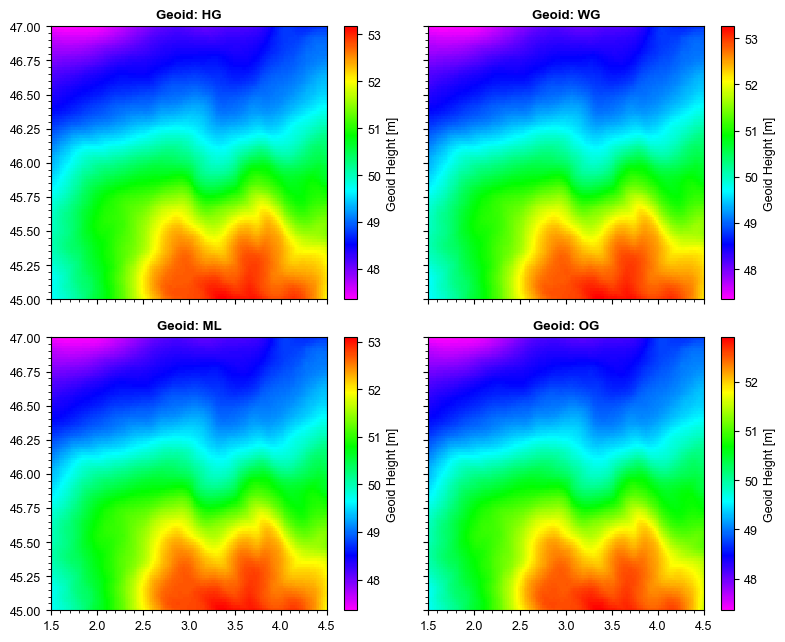

In [54]:
plt.rcParams.update({'font.family': 'Arial', 'font.size': 9})
fig, axs = plt.subplots(2, 2, figsize=[8, 6.5], sharex=True, sharey=True)
axs = axs.ravel()

for (key, value), ax in zip(geoid_dict.items(), axs):
    method = key.upper()
    im = ax.pcolormesh(value.lon, value.lat, value['N'], cmap=get_colormap('GMT_rainbow.cpt'))
    fig.colorbar(im, ax=ax, label='Geoid Height [m]')
    ax.set_title(f'Geoid: {method.upper()}', fontweight='bold', fontsize=9.5)
    ax.grid(which='both', linewidth=0)
    ax.minorticks_on()
    ax.grid(which='minor', linewidth=0)

fig.tight_layout()
plt.savefig(figures_dir / 'N_all.png', dpi=300, bbox_inches='tight')
plt.show()

Excellent! We will now interpolate gravimetric geoid heights at the GNSS/leveling locations. Let's create a handy function to do this!

In [55]:
import numpy as np
def interpolate_geoid_at_gnss(geoid_dict, gnss_df, interp_method='linear') -> dict:
    '''
    Interpolates geoid heights at the lat-lon positions in gnss_df for each method in geoid_dict.

    Parameters
    ----------
    geoid_dict      : Dictionary of xarray Datasets, each with variables 'lat', 'lon', and 'N'.
    gnss_df         : DataFrame with columns ['lat', 'lon', 'N'] (N is ignored here).
    interp_method   : Method for interpolation

    Returns
    -------
    interp_dict     : Dictionary with same keys as geoid_dict, values are np.arrays of interpolated geoid heights at gnss_df points.
    '''
    from scipy.interpolate import RegularGridInterpolator

    interp_dict = {}
    for method, ds in geoid_dict.items():
        lats = ds.lat.values
        lons = ds.lon.values
        if (np.diff(lats) < 0).any():
            lats = lats[::-1]
            N = ds['N'].values[::-1, :]
        else:
            N = ds['N'].values
        if (np.diff(lons) < 0).any():
            lons = lons[::-1]
            N = N[:, ::-1]
        # Build interpolator
        interp = RegularGridInterpolator((lats, lons), N, bounds_error=False, fill_value=np.nan, method=interp_method)
        points = np.column_stack([gnss_df['lat'].values, gnss_df['lon'].values])
        interp_dict[method] = interp(points)
    return interp_dict

In [56]:
gnss_grav_N: dict = interpolate_geoid_at_gnss(geoid_dict, gnss_df, interp_method='cubic')

Great! Now that we have loaded the requisite data and interpolated our gravimetric geoid heights at the GNSS/leveling stations, let's go on ahead to write a function to perform the validation. We are using the same 4-parameter corrector surface model used in Abbak et al. (2024) for good measure!

How does this work? Researchers have shown that there may be (there often are) systematic biases between GNSS/leveling and gravimetric geoid undulations. This means that simply calculating their difference and the summary statistics (min, max, mean, standard deviation) will fail to capture their true relationship (or difference). Therefore, we must model and remove these systematic biases.

There are a number of models ($a^\text{T}\mathbf{x}$) that are often used for this, having the general form of:
\begin{equation}
N - N_\text{GNSS/leveling} = \delta N + a^\text{T}\mathbf{x},
\end{equation}
where $a^\text{T}\mathbf{x}$ captures the sytematic effects; thus allowing for more realistic $\delta N$ values.

However, in keeping with the comparison with `CSHSOFT`, we will implement the 4-parameter model here. 

The 4-parameter model is defined as ([Kotsakis 2012](https://link.springer.com/article/10.1007/s00190-011-0530-7)):
\begin{equation}
a^\text{T}\mathbf{x} = x_0 + x_1\cos\varphi_i\cos\lambda_i + x_2\cos\varphi_i\sin\lambda_i + x_3\sin\varphi_i,
\end{equation}
where $\varphi_i$ and $\lambda_i$ are the latitude and longitude of the GNSS station $i$, and $x_i$ ($i \in 0, 1, 2, 3$) are the model parameters.

The objective is to obtain estimates for $x_i$ (i.e., $\hat{x}_0, \hat{x}_1, \cdots$).

## Corrector Surface

In [134]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def four_parm_surface(gnss: pd.DataFrame, geoid: np.array, return_model=False):
    '''
    Computes 4-parameter bias model between gravimetric geoid and GNSS/leveling undulations
    
    Parameters
    ----------
    gnss         : DataFrame with columns ['lat', 'lon', 'N'] 
                   Contains GNSS/leveling undulations and positions
    geoid        : 1D array of gravimetric geoid undulations at gnss points
    return_model : Whether to return full regression model (default False)
    
    Returns
    -------
    x_hat     : Estimated parameters [x0, x1, x2, x3]
    residuals : Unbiased differences (δN) after bias removal
    model     : (Optional) statsmodels regression results object
    '''
    # Convert degrees to radians
    lat_rad = np.deg2rad(gnss['lat'].values)
    lon_rad = np.deg2rad(gnss['lon'].values)
    
    # Calculate differences
    dN = geoid - gnss['N'].values
    
    # Build design matrix with statsmodels
    A = sm.add_constant(np.column_stack((
        np.cos(lat_rad) * np.cos(lon_rad),
        np.cos(lat_rad) * np.sin(lon_rad),
        np.sin(lat_rad)
    )))
    
    # Create and fit OLS model
    model = sm.OLS(dN, A).fit()
    predicted = model.fittedvalues
    if return_model:
        return model.params, model.resid, predicted, model
    return model.params, model.resid, predicted

The two key parameters that `four_parm_surface` takes are `gnss` and `geoid`. `gnss` must be a Pandas DataFrame with columns `['lat', 'lon', 'N']`. `geoid` is simply a 1D Numpy array (e.g., `gnss_grav_N['hg']`). Let's see how our validation goes...

In [133]:
residuals_dict: dict = {}
params_dict: dict = {}
predictions_dict: dict = {}

for method, gnss_N in gnss_grav_N.items():
    params_dict[method], residuals_dict[method], predictions_dict[method] = four_parm_surface(gnss_df, gnss_N)


for method, residual_cm in residuals_dict.items():
    residual_cm *= 100 # m to cm
    print(f"Method: {method.upper()}")
    print(f"  Min : {residual_cm.min():.6f}")
    print(f"  Max : {residual_cm.max():.6f}")
    print(f"  Mean: {residual_cm.mean():.6f}")
    # print(f"  Std : {np.std(residual_cm):.6f}")
    print(f"  RMS : {np.sqrt(np.mean(residual_cm**2)):.6f}")
    print()


(75, 4)
(75, 4)
(75, 4)
(75, 4)
Method: HG
  Min : -9.948676
  Max : 6.267743
  Mean: 0.000000
  RMS : 2.841857

Method: WG
  Min : -7.591159
  Max : 7.461373
  Mean: -0.000000
  RMS : 2.867998

Method: ML
  Min : -8.595744
  Max : 6.925564
  Mean: 0.000000
  RMS : 2.944251

Method: OG
  Min : -13.992302
  Max : 9.490992
  Mean: 0.000000
  RMS : 4.300588



## Direct Comparison

In [59]:
for method, gnss_N in gnss_grav_N.items():
    diff = np.abs(gnss_df['N'].values - gnss_N)
    diff *= 100 # m to cm
    print(f"Method: {method.upper()}")
    print(f"  Min diff:   {diff.min():.6f}")
    print(f"  Max diff:   {diff.max():.6f}")
    print(f"  Mean diff:  {diff.mean():.6f}")
    print(f"  Std diff:   {np.std(diff):.6f}")
    print()

Method: HG
  Min diff:   71.889666
  Max diff:   91.906988
  Mean diff:  82.534479
  Std diff:   4.861569

Method: WG
  Min diff:   79.170685
  Max diff:   95.104371
  Mean diff:  86.305085
  Std diff:   3.767486

Method: ML
  Min diff:   67.443345
  Max diff:   92.337921
  Mean diff:  80.080115
  Std diff:   6.544811

Method: OG
  Min diff:   44.701858
  Max diff:   92.966974
  Mean diff:  71.448817
  Std diff:   12.774655

